# Final Task-Type Detector: LOSO Comparison on Full Dataset
This notebook loads the full fusion dataset, runs leave-one-subject-out (LOSO) evaluation on 10 tabular models, saves per-fold artifacts, and produces a scientific comparison to identify the best performer. The summary uses mean/std across folds and paired statistical tests, not bootstrap confidence intervals.

In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

from scipy.stats import friedmanchisquare, wilcoxon
from tqdm.auto import tqdm

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
DATASET = Path('/home/g0amer/Desktop/thesis/research_outputs/fusion/v1_fusion/fusion_dataset.csv')
OUT_ROOT = Path('/home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models')
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print('dataset:', DATASET)
print('out root:', OUT_ROOT)
print('xgboost available:', HAS_XGB)

dataset: /home/g0amer/Desktop/thesis/research_outputs/fusion/v1_fusion/fusion_dataset.csv
out root: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models
xgboost available: False


In [4]:
df = pd.read_csv(DATASET, low_memory=False)
if 'pseudo_label' not in df.columns:
    raise RuntimeError('expected pseudo_label column in the dataset')

subject_col = 'subject_id'
if subject_col not in df.columns:
    raise RuntimeError('expected subject_id column in the dataset')

exclude = {
    'subject_id', 'task_name', 'task_file', 'split', 'window_idx',
    'start_idx', 'end_idx', 'n_samples', 'pseudo_label', 'label',
    'eeg_features_5s__split', 'n_modalities_present'
}
feature_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
labels = sorted(df['pseudo_label'].astype(str).unique())
subjects = sorted(df['subject_id'].unique())

print('rows:', len(df))
print('subjects:', len(subjects))
print('classes:', labels)
print('features:', len(feature_cols))
print('class counts:')
print(df['pseudo_label'].value_counts())
print('feature NaNs:', int(df[feature_cols].isna().sum().sum()))

rows: 5640
subjects: 52
classes: ['cognitive_load', 'high_stress', 'industrial_task', 'low_load', 'other']
features: 246
class counts:
pseudo_label
industrial_task    3571
cognitive_load      975
low_load            799
high_stress         224
other                71
Name: count, dtype: int64
feature NaNs: 328


In [5]:
def make_models():
    models = {
        'logreg': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'random_forest': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        'extra_trees': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', ExtraTreesClassifier(n_estimators=400, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        'gradient_boosting': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        'hist_gradient_boosting': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        'svm_rbf': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', probability=False, random_state=RANDOM_STATE))
        ]),
        'knn': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=7, weights='distance'))
        ]),
        'decision_tree': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE, max_depth=None))
        ]),
        'gaussian_nb': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', GaussianNB())
        ]),
        'mlp': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=600, random_state=RANDOM_STATE, early_stopping=False))
        ]),
    }
    if HAS_XGB:
        models['xgboost'] = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('clf', XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective='multi:softprob',
                eval_metric='mlogloss',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    return models

def fold_labels():
    return sorted(df['pseudo_label'].astype(str).unique())

def fold_dir(model_name):
    d = OUT_ROOT / model_name / 'folds'
    d.mkdir(parents=True, exist_ok=True)
    return d

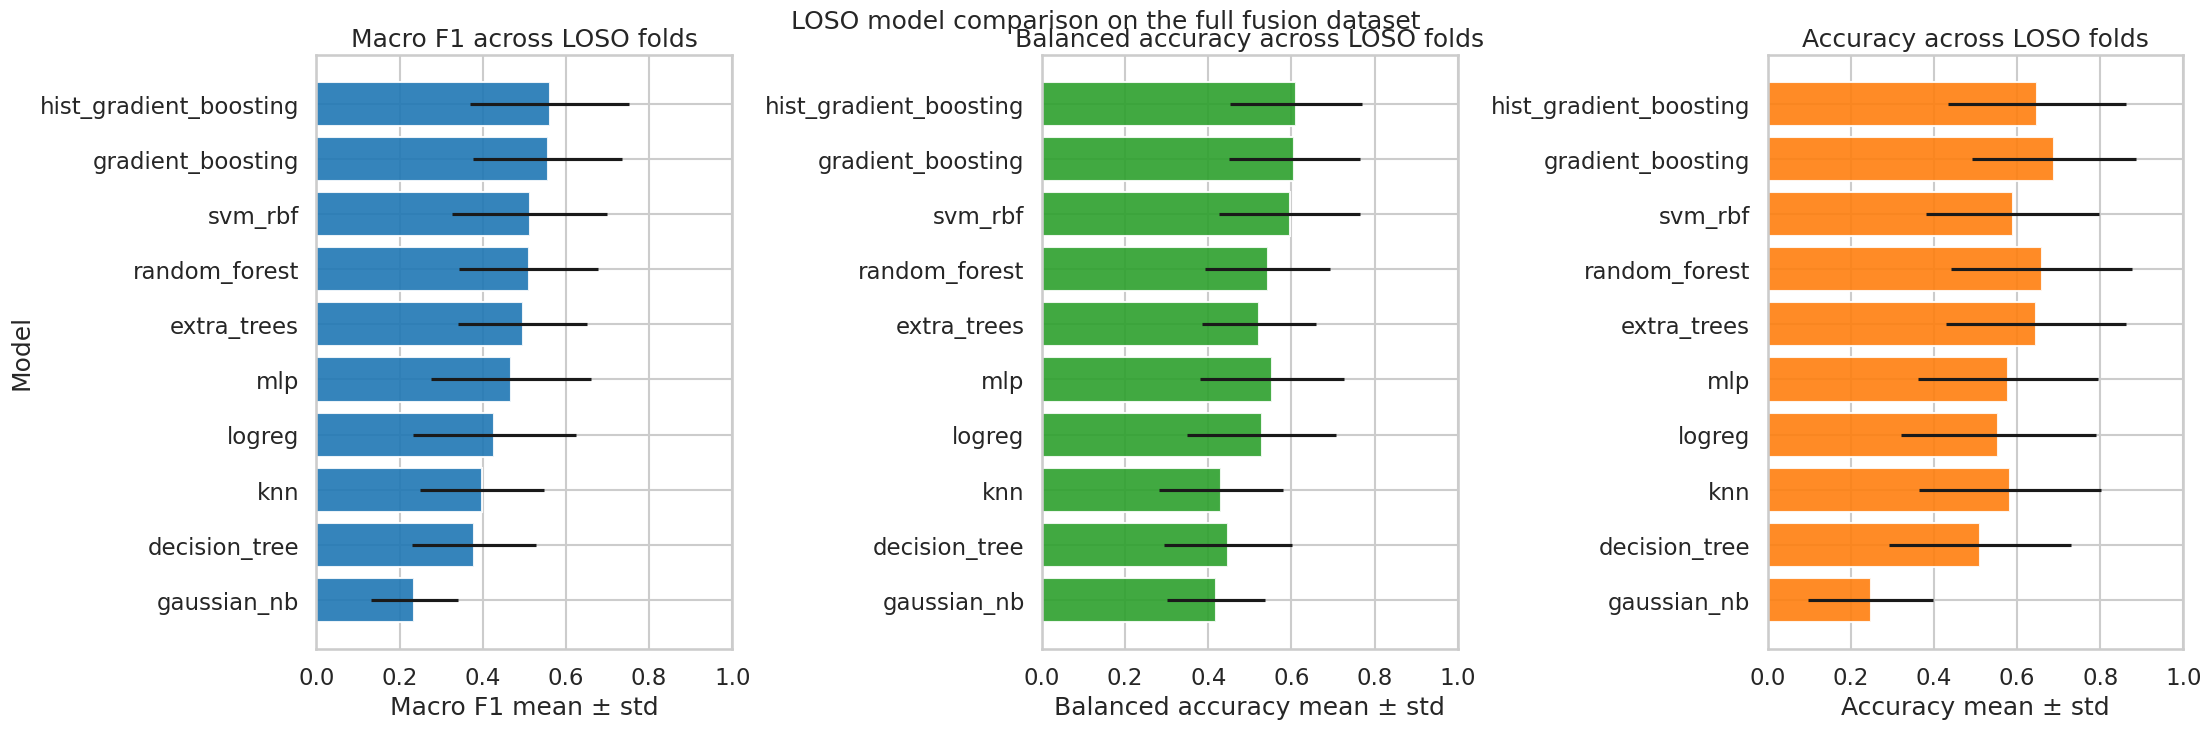

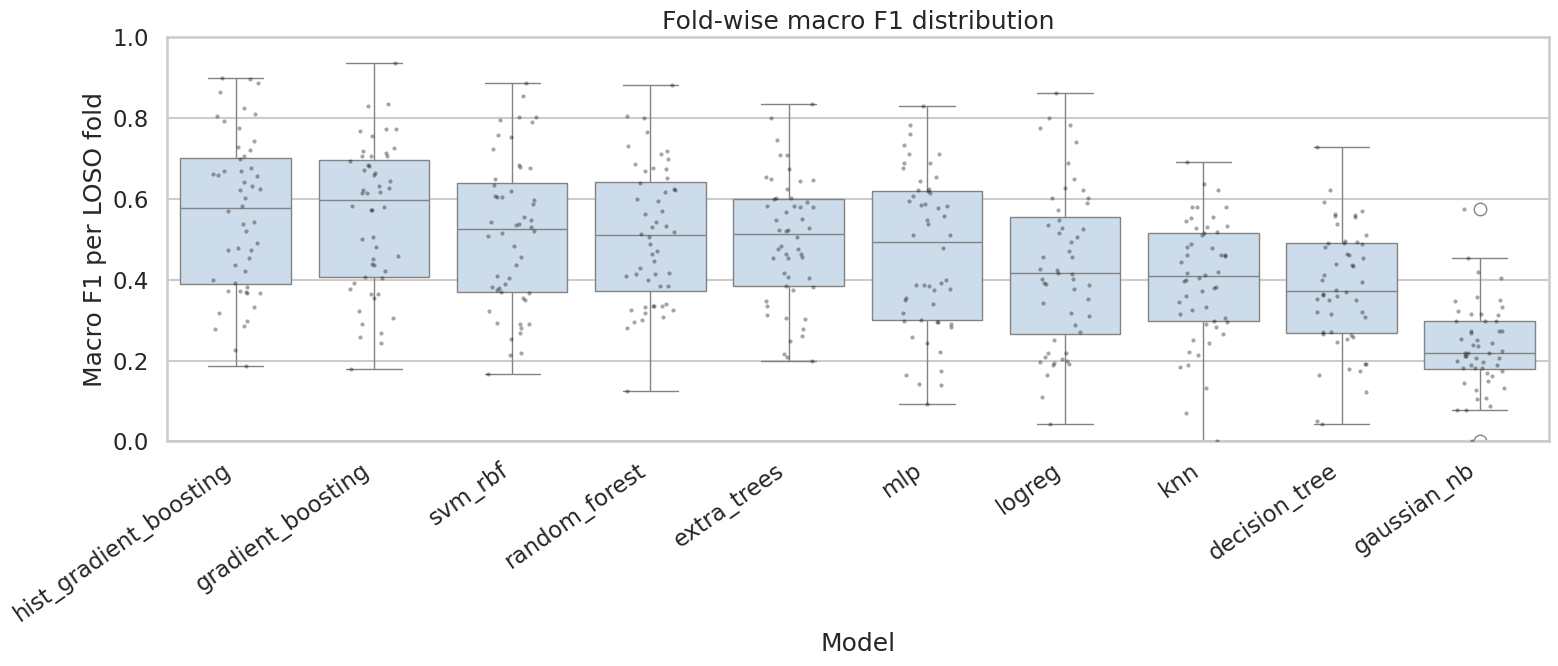

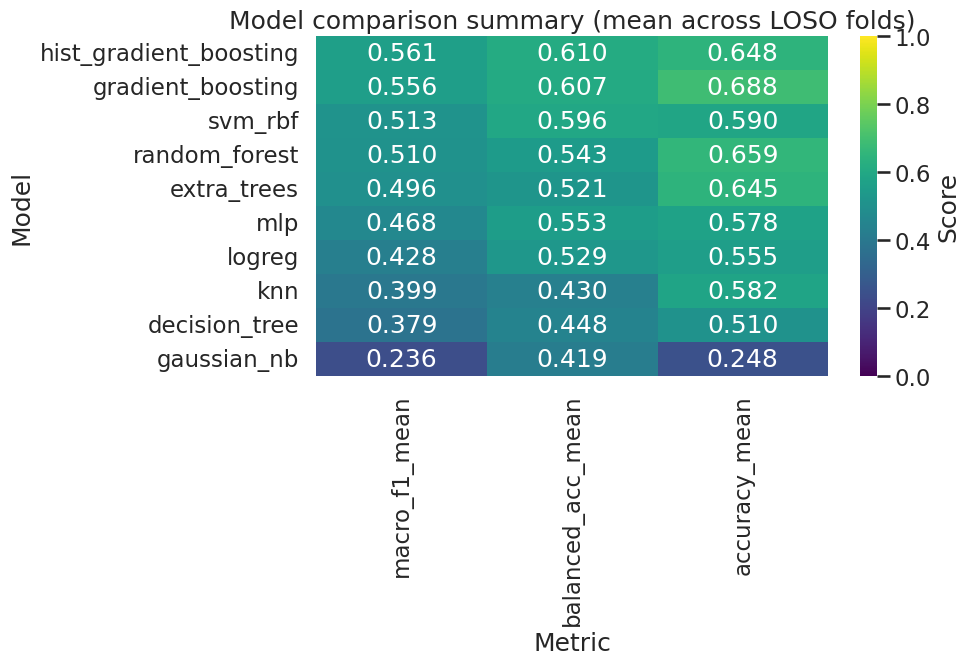

Saved figures to /home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models
Available figures: comparison_metrics_bars.png/.svg, comparison_macro_f1_boxplot.png/.svg, comparison_metric_heatmap.png/.svg


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

# Build the summary from whatever model fold files already exist so this cell
# can be run on its own after individual model cells.
summary_rows = []
for model_name in make_models().keys():
    fold_path = OUT_ROOT / model_name / 'fold_metrics.csv'
    if not fold_path.exists():
        continue
    fold_df = pd.read_csv(fold_path)
    if fold_df.empty:
        continue
    summary_rows.append({
        'model': model_name,
        'n_folds': int(len(fold_df)),
        'accuracy_mean': float(fold_df['accuracy'].mean()),
        'accuracy_std': float(fold_df['accuracy'].std()),
        'balanced_acc_mean': float(fold_df['balanced_acc'].mean()),
        'balanced_acc_std': float(fold_df['balanced_acc'].std()),
        'macro_f1_mean': float(fold_df['macro_f1'].mean()),
        'macro_f1_std': float(fold_df['macro_f1'].std()),
    })

if not summary_rows:
    raise RuntimeError('No fold_metrics.csv files found. Run at least one model cell first.')

summary_df = pd.DataFrame(summary_rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
summary_df.to_csv(OUT_ROOT / 'benchmark_summary.csv', index=False)
summary_df['rank_macro_f1'] = np.arange(1, len(summary_df) + 1)
summary_df['rank_balanced_acc'] = summary_df['balanced_acc_mean'].rank(ascending=False, method='min').astype(int)
summary_df['rank_accuracy'] = summary_df['accuracy_mean'].rank(ascending=False, method='min').astype(int)
summary_df.to_csv(OUT_ROOT / 'benchmark_summary_ranked.csv', index=False)

# Comparison figures for the benchmark summary
summary_plot = summary_df.copy().sort_values('macro_f1_mean', ascending=True).reset_index(drop=True)
summary_plot['macro_f1_sem'] = summary_plot['macro_f1_std'] / np.sqrt(summary_plot['n_folds'].clip(lower=1))
summary_plot['balanced_acc_sem'] = summary_plot['balanced_acc_std'] / np.sqrt(summary_plot['n_folds'].clip(lower=1))
summary_plot['accuracy_sem'] = summary_plot['accuracy_std'] / np.sqrt(summary_plot['n_folds'].clip(lower=1))

fig, axes = plt.subplots(1, 3, figsize=(22, 7), constrained_layout=True)

# Panel 1: macro F1 ranking
axes[0].barh(summary_plot['model'], summary_plot['macro_f1_mean'], xerr=summary_plot['macro_f1_std'], color='#1f77b4', alpha=0.9)
axes[0].set_title('Macro F1 across LOSO folds')
axes[0].set_xlabel('Macro F1 mean ± std')
axes[0].set_ylabel('Model')
axes[0].set_xlim(0, 1)

# Panel 2: balanced accuracy ranking
axes[1].barh(summary_plot['model'], summary_plot['balanced_acc_mean'], xerr=summary_plot['balanced_acc_std'], color='#2ca02c', alpha=0.9)
axes[1].set_title('Balanced accuracy across LOSO folds')
axes[1].set_xlabel('Balanced accuracy mean ± std')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)

# Panel 3: accuracy ranking
axes[2].barh(summary_plot['model'], summary_plot['accuracy_mean'], xerr=summary_plot['accuracy_std'], color='#ff7f0e', alpha=0.9)
axes[2].set_title('Accuracy across LOSO folds')
axes[2].set_xlabel('Accuracy mean ± std')
axes[2].set_ylabel('')
axes[2].set_xlim(0, 1)

fig.suptitle('LOSO model comparison on the full fusion dataset', fontsize=18, y=1.02)
fig.savefig(OUT_ROOT / 'comparison_metrics_bars.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_ROOT / 'comparison_metrics_bars.svg', bbox_inches='tight')
plt.show()

# Fold-wise distribution figure for macro F1
fold_long = []
for model_name in summary_df['model'].tolist():
    fold_df = pd.read_csv(OUT_ROOT / model_name / 'fold_metrics.csv')
    fold_df = fold_df[['model', 'subject_id', 'macro_f1', 'balanced_acc', 'accuracy']].copy()
    fold_long.append(fold_df)
fold_long = pd.concat(fold_long, ignore_index=True)

plt.figure(figsize=(16, 7))
sns.boxplot(data=fold_long, x='model', y='macro_f1', order=summary_df['model'].tolist(), color='#c7dcef')
sns.stripplot(data=fold_long, x='model', y='macro_f1', order=summary_df['model'].tolist(), color='black', alpha=0.35, size=3, jitter=0.18)
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.xlabel('Model')
plt.ylabel('Macro F1 per LOSO fold')
plt.title('Fold-wise macro F1 distribution')
plt.tight_layout()
plt.savefig(OUT_ROOT / 'comparison_macro_f1_boxplot.png', dpi=300, bbox_inches='tight')
plt.savefig(OUT_ROOT / 'comparison_macro_f1_boxplot.svg', bbox_inches='tight')
plt.show()

# Metric heatmap of model means
heatmap_df = summary_df.set_index('model')[['macro_f1_mean', 'balanced_acc_mean', 'accuracy_mean']]
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1, cbar_kws={'label': 'Score'})
plt.title('Model comparison summary (mean across LOSO folds)')
plt.xlabel('Metric')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(OUT_ROOT / 'comparison_metric_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig(OUT_ROOT / 'comparison_metric_heatmap.svg', bbox_inches='tight')
plt.show()

print('Saved figures to', OUT_ROOT)
print('Available figures: comparison_metrics_bars.png/.svg, comparison_macro_f1_boxplot.png/.svg, comparison_metric_heatmap.png/.svg')

In [17]:
best_model = summary_df.iloc[0]['model']
best_path = OUT_ROOT / best_model / 'final_model.joblib'
best_model_obj = joblib.load(best_path)
sample_pred = best_model_obj.predict(df[feature_cols].iloc[:10].values)
print('best model:', best_model)
print('best model path:', best_path)
print('sample predictions:', sample_pred)

result_manifest = {
    'dataset': str(DATASET),
    'output_root': str(OUT_ROOT),
    'best_model': str(best_model),
    'summary_csv': str(OUT_ROOT / 'benchmark_summary.csv'),
    'ranked_csv': str(OUT_ROOT / 'benchmark_summary_ranked.csv'),
    'pairwise_csv': str(OUT_ROOT / 'pairwise_vs_best.csv'),
}
with open(OUT_ROOT / 'manifest.json', 'w') as f:
    json.dump(result_manifest, f, indent=2)
print(json.dumps(result_manifest, indent=2))

best model: hist_gradient_boosting
best model path: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models/hist_gradient_boosting/final_model.joblib
sample predictions: ['industrial_task' 'industrial_task' 'industrial_task' 'industrial_task'
 'industrial_task' 'industrial_task' 'industrial_task' 'industrial_task'
 'industrial_task' 'industrial_task']
{
  "dataset": "/home/g0amer/Desktop/thesis/research_outputs/fusion/v1_fusion/fusion_dataset.csv",
  "output_root": "/home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models",
  "best_model": "hist_gradient_boosting",
  "summary_csv": "/home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models/benchmark_summary.csv",
  "ranked_csv": "/home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models/benchmark_summary_ranked.csv",
  "pairwise_csv": "/home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detec

## What this notebook produces
- Per-model LOSO fold CSVs with accuracy, balanced accuracy, and macro F1.
- Per-fold classification reports and confusion matrices.
- A ranked benchmark summary with mean/std aggregation across folds.
- Comparison figures for the model benchmark: metric bar charts, fold-wise macro F1 boxplots, and a mean-metric heatmap.
- A saved final model for each candidate classifier.

In [18]:
def run_loso_model(model_name, df, feature_cols):
    """Run LOSO for a single model and save per-fold artifacts and final model."""
    model_registry = make_models()
    if model_name not in model_registry:
        raise RuntimeError(f'model {model_name} not found in registry')
    pipeline = model_registry[model_name]
    classes = fold_labels()

    model_root = OUT_ROOT / model_name
    model_root.mkdir(parents=True, exist_ok=True)
    model_folds = fold_dir(model_name)

    fold_rows = []
    for subject in tqdm(subjects, desc=f'{model_name} LOSO', total=len(subjects)):
        train_mask = df['subject_id'] != subject
        test_mask = df['subject_id'] == subject
        train_df = df.loc[train_mask]
        test_df = df.loc[test_mask]
        if test_df.empty:
            continue

        X_train = train_df[feature_cols].values
        y_train = train_df['pseudo_label'].astype(str).values
        X_test = test_df[feature_cols].values
        y_test = test_df['pseudo_label'].astype(str).values

        model = pipeline
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_metric = {
            'model': model_name,
            'subject_id': int(subject),
            'n_test': int(len(y_test)),
            'accuracy': float(accuracy_score(y_test, y_pred)),
            'balanced_acc': float(balanced_accuracy_score(y_test, y_pred)),
            'macro_f1': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
        }
        fold_rows.append(fold_metric)

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=classes)

        pd.DataFrame([fold_metric]).to_csv(model_folds / f'fold_{int(subject):02d}.csv', index=False)
        pd.DataFrame(report).T.to_csv(model_folds / f'fold_{int(subject):02d}_per_class.csv')
        pd.DataFrame(cm, index=classes, columns=classes).to_csv(model_folds / f'fold_{int(subject):02d}_confusion.csv')

    fold_df = pd.DataFrame(fold_rows)
    fold_df.to_csv(model_root / 'fold_metrics.csv', index=False)

    print(f'Fitting final model for {model_name}', flush=True)
    final_model = pipeline
    final_model.fit(df[feature_cols].values, df['pseudo_label'].astype(str).values)
    joblib.dump(final_model, model_root / 'final_model.joblib')

    print(f'Completed LOSO for {model_name}: {len(fold_df)} folds', flush=True)
    return fold_df

In [19]:
# Run this cell to execute only the logistic regression LOSO benchmark.
logreg_fold_df = run_loso_model('logreg', df, feature_cols)
logreg_fold_df

logreg LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for logreg
Completed LOSO for logreg: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,logreg,1001,117,0.222222,0.410526,0.287204
1,logreg,1002,47,0.531915,0.549107,0.417935
2,logreg,1005,155,0.761290,0.393853,0.341613
3,logreg,1006,28,0.392857,0.375947,0.311111
4,logreg,1007,135,0.237037,0.283022,0.200048
5,logreg,1008,153,0.810458,0.610445,0.527341
6,logreg,1009,37,0.189189,0.383814,0.195556
7,logreg,1013,18,0.333333,0.466667,0.217544
8,logreg,1014,22,0.181818,0.250000,0.191270
9,logreg,1015,21,0.523810,0.568254,0.424908


In [20]:
# Run this cell to execute only the random forest LOSO benchmark.
random_forest_fold_df = run_loso_model('random_forest', df, feature_cols)
random_forest_fold_df

random_forest LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for random_forest
Completed LOSO for random_forest: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,random_forest,1001,117,0.735043,0.560417,0.517764
1,random_forest,1002,47,0.553191,0.528274,0.409982
2,random_forest,1005,155,0.754839,0.461827,0.414272
3,random_forest,1006,28,0.357143,0.503788,0.318357
4,random_forest,1007,135,0.325926,0.369427,0.308349
5,random_forest,1008,153,0.542484,0.543705,0.383567
6,random_forest,1009,37,0.108108,0.333333,0.300000
7,random_forest,1013,18,0.055556,0.166667,0.125000
8,random_forest,1014,22,0.272727,0.444444,0.325000
9,random_forest,1015,21,0.380952,0.400000,0.333333


In [21]:
# Run this cell to execute only the extra trees LOSO benchmark.
extra_trees_fold_df = run_loso_model('extra_trees', df, feature_cols)
extra_trees_fold_df

extra_trees LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for extra_trees
Completed LOSO for extra_trees: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,extra_trees,1001,117,0.743590,0.548136,0.524199
1,extra_trees,1002,47,0.468085,0.500000,0.417424
2,extra_trees,1005,155,0.838710,0.512274,0.475212
3,extra_trees,1006,28,0.214286,0.314394,0.248889
4,extra_trees,1007,135,0.348148,0.394907,0.302481
5,extra_trees,1008,153,0.843137,0.619791,0.528098
6,extra_trees,1009,37,0.081081,0.291667,0.217143
7,extra_trees,1013,18,0.111111,0.333333,0.200000
8,extra_trees,1014,22,0.272727,0.444444,0.375000
9,extra_trees,1015,21,0.238095,0.238095,0.208333


In [22]:
# Run this cell to execute only the gradient boosting LOSO benchmark.
gradient_boosting_fold_df = run_loso_model('gradient_boosting', df, feature_cols)
gradient_boosting_fold_df

gradient_boosting LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for gradient_boosting
Completed LOSO for gradient_boosting: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,gradient_boosting,1001,117,0.521368,0.534101,0.481189
1,gradient_boosting,1002,47,0.617021,0.514881,0.323598
2,gradient_boosting,1005,155,0.806452,0.447627,0.405541
3,gradient_boosting,1006,28,0.464286,0.571970,0.377406
4,gradient_boosting,1007,135,0.644444,0.425588,0.364771
5,gradient_boosting,1008,153,0.862745,0.645190,0.583364
6,gradient_boosting,1009,37,0.486486,0.604167,0.501176
7,gradient_boosting,1013,18,0.277778,0.566667,0.180392
8,gradient_boosting,1014,22,0.545455,0.722222,0.458929
9,gradient_boosting,1015,21,0.809524,0.792593,0.631944


In [23]:
# Run this cell to execute only the histogram gradient boosting LOSO benchmark.
hist_gradient_boosting_fold_df = run_loso_model('hist_gradient_boosting', df, feature_cols)
hist_gradient_boosting_fold_df

hist_gradient_boosting LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for hist_gradient_boosting
Completed LOSO for hist_gradient_boosting: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,hist_gradient_boosting,1001,117,0.393162,0.510033,0.366743
1,hist_gradient_boosting,1002,47,0.595745,0.605655,0.489857
2,hist_gradient_boosting,1005,155,0.735484,0.459325,0.390820
3,hist_gradient_boosting,1006,28,0.500000,0.613636,0.400000
4,hist_gradient_boosting,1007,135,0.600000,0.393251,0.372909
5,hist_gradient_boosting,1008,153,0.856209,0.692798,0.603060
6,hist_gradient_boosting,1009,37,0.405405,0.531250,0.380952
7,hist_gradient_boosting,1013,18,0.333333,0.600000,0.297619
8,hist_gradient_boosting,1014,22,0.454545,0.666667,0.369318
9,hist_gradient_boosting,1015,21,0.809524,0.792593,0.792593


In [24]:
# Run this cell to execute only the svm_rbf LOSO benchmark.
svm_rbf_fold_df = run_loso_model('svm_rbf', df, feature_cols)
svm_rbf_fold_df

svm_rbf LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for svm_rbf
Completed LOSO for svm_rbf: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,svm_rbf,1001,117,0.452991,0.494901,0.381761
1,svm_rbf,1002,47,0.489362,0.578869,0.368473
2,svm_rbf,1005,155,0.625806,0.345591,0.289902
3,svm_rbf,1006,28,0.500000,0.613636,0.370714
4,svm_rbf,1007,135,0.244444,0.325604,0.214134
5,svm_rbf,1008,153,0.849673,0.681034,0.596547
6,svm_rbf,1009,37,0.297297,0.442708,0.269279
7,svm_rbf,1013,18,0.222222,0.533333,0.281250
8,svm_rbf,1014,22,0.227273,0.388889,0.293651
9,svm_rbf,1015,21,0.571429,0.548148,0.408333


In [25]:
# Run this cell to execute only the knn LOSO benchmark.
knn_fold_df = run_loso_model('knn', df, feature_cols)
knn_fold_df

knn LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for knn
Completed LOSO for knn: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,knn,1001,117,0.683761,0.444243,0.444178
1,knn,1002,47,0.063830,0.062500,0.070769
2,knn,1005,155,0.690323,0.292185,0.282118
3,knn,1006,28,0.321429,0.321970,0.345000
4,knn,1007,135,0.377778,0.250697,0.244463
5,knn,1008,153,0.816993,0.552859,0.552101
6,knn,1009,37,0.162162,0.316106,0.214079
7,knn,1013,18,0.000000,0.000000,0.000000
8,knn,1014,22,0.090909,0.166667,0.133333
9,knn,1015,21,0.190476,0.179894,0.188462


In [26]:
# Run this cell to execute only the decision tree LOSO benchmark.
decision_tree_fold_df = run_loso_model('decision_tree', df, feature_cols)
decision_tree_fold_df

decision_tree LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for decision_tree
Completed LOSO for decision_tree: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,decision_tree,1001,117,0.726496,0.587500,0.537191
1,decision_tree,1002,47,0.234043,0.270833,0.175000
2,decision_tree,1005,155,0.735484,0.437835,0.373775
3,decision_tree,1006,28,0.464286,0.590909,0.370403
4,decision_tree,1007,135,0.177778,0.230186,0.192156
5,decision_tree,1008,153,0.869281,0.656954,0.557418
6,decision_tree,1009,37,0.216216,0.421875,0.320000
7,decision_tree,1013,18,0.111111,0.066667,0.042105
8,decision_tree,1014,22,0.363636,0.416667,0.257778
9,decision_tree,1015,21,0.238095,0.257143,0.253247


In [27]:
# Run this cell to execute only the gaussian naive bayes LOSO benchmark.
gaussian_nb_fold_df = run_loso_model('gaussian_nb', df, feature_cols)
gaussian_nb_fold_df

gaussian_nb LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for gaussian_nb
Completed LOSO for gaussian_nb: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,gaussian_nb,1001,117,0.213675,0.424561,0.348876
1,gaussian_nb,1002,47,0.425532,0.497619,0.419763
2,gaussian_nb,1005,155,0.148387,0.231579,0.086751
3,gaussian_nb,1006,28,0.464286,0.540720,0.454106
4,gaussian_nb,1007,135,0.237037,0.329078,0.205530
5,gaussian_nb,1008,153,0.176471,0.413109,0.268971
6,gaussian_nb,1009,37,0.378378,0.441106,0.297276
7,gaussian_nb,1013,18,0.277778,0.433333,0.250000
8,gaussian_nb,1014,22,0.136364,0.250000,0.150000
9,gaussian_nb,1015,21,0.476190,0.444444,0.333333


In [28]:
# Run this cell to execute only the mlp LOSO benchmark.
mlp_fold_df = run_loso_model('mlp', df, feature_cols)
mlp_fold_df

mlp LOSO:   0%|          | 0/52 [00:00<?, ?it/s]

Fitting final model for mlp
Completed LOSO for mlp: 52 folds


,model,subject_id,n_test,accuracy,balanced_acc,macro_f1
0,mlp,1001,117,0.290598,0.462025,0.348998
1,mlp,1002,47,0.297872,0.316667,0.174673
2,mlp,1005,155,0.658065,0.372304,0.300651
3,mlp,1006,28,0.214286,0.193182,0.140000
4,mlp,1007,135,0.170370,0.211385,0.091412
5,mlp,1008,153,0.764706,0.597361,0.510593
6,mlp,1009,37,0.405405,0.505208,0.318919
7,mlp,1013,18,0.166667,0.366667,0.142361
8,mlp,1014,22,0.227273,0.361111,0.298611
9,mlp,1015,21,0.619048,0.633862,0.387186


In [7]:
# Aggregate per-model fold_metrics.csv into the benchmark summary (run after you've executed individual model cells)
summary_rows = []
for model_name in make_models().keys():
    fold_path = OUT_ROOT / model_name / 'fold_metrics.csv'
    if not fold_path.exists():
        print('No results for', model_name)
        continue
    fold_df = pd.read_csv(fold_path)
    if fold_df.empty:
        continue
    summary_rows.append({
        'model': model_name,
        'n_folds': int(len(fold_df)),
        'accuracy_mean': float(fold_df['accuracy'].mean()),
        'accuracy_std': float(fold_df['accuracy'].std()),
        'balanced_acc_mean': float(fold_df['balanced_acc'].mean()),
        'balanced_acc_std': float(fold_df['balanced_acc'].std()),
        'macro_f1_mean': float(fold_df['macro_f1'].mean()),
        'macro_f1_std': float(fold_df['macro_f1'].std()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
summary_df.to_csv(OUT_ROOT / 'benchmark_summary.csv', index=False)
print(summary_df)

# Also save ranked
summary_df['rank_macro_f1'] = np.arange(1, len(summary_df) + 1)
summary_df['rank_balanced_acc'] = summary_df['balanced_acc_mean'].rank(ascending=False, method='min').astype(int)
summary_df['rank_accuracy'] = summary_df['accuracy_mean'].rank(ascending=False, method='min').astype(int)
summary_df.to_csv(OUT_ROOT / 'benchmark_summary_ranked.csv', index=False)
print('Wrote benchmark_summary.csv and benchmark_summary_ranked.csv')

                    model  n_folds  accuracy_mean  accuracy_std  \
0  hist_gradient_boosting       52       0.647689      0.213076   
1       gradient_boosting       52       0.688296      0.197611   
2                 svm_rbf       52       0.589640      0.207948   
3           random_forest       52       0.659066      0.217106   
4             extra_trees       52       0.644964      0.217094   
5                     mlp       52       0.577731      0.217126   
6                  logreg       52       0.555158      0.234071   
7                     knn       52       0.582489      0.219043   
8           decision_tree       52       0.510283      0.218537   
9             gaussian_nb       52       0.247682      0.150949   

   balanced_acc_mean  balanced_acc_std  macro_f1_mean  macro_f1_std  
0           0.610241          0.158985       0.561498      0.191240  
1           0.607183          0.156467       0.556116      0.179345  
2           0.595783          0.169527       0.51282

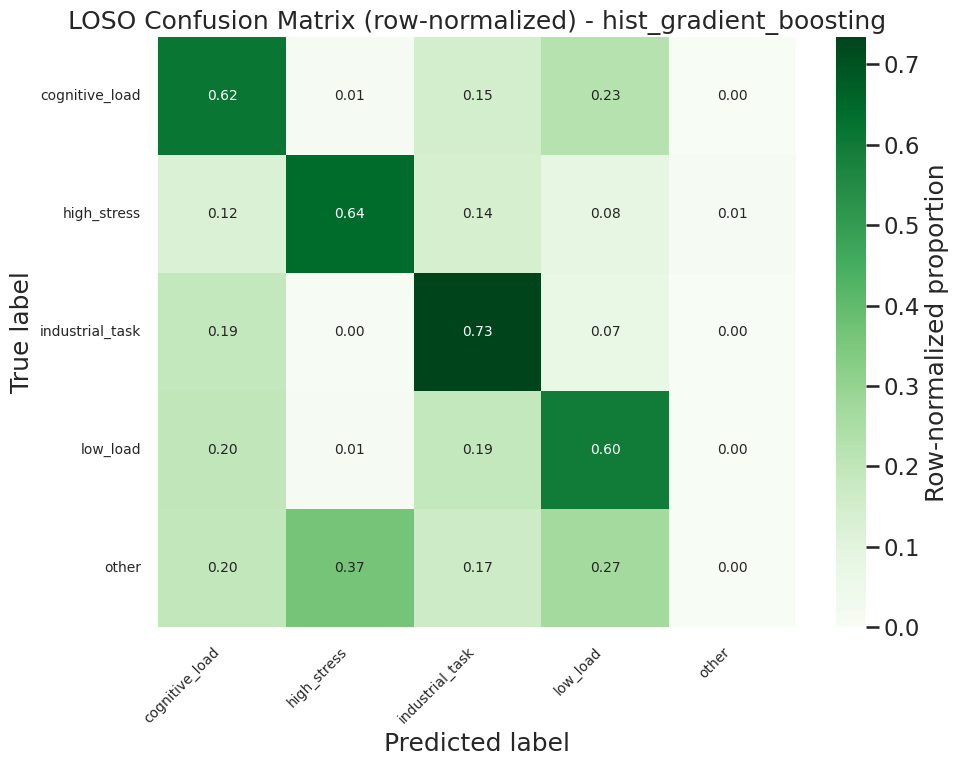

Saved confusion matrix to /home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models/confusion_matrix_loso_hist_gradient_boosting_normalized.png
Saved confusion matrix to /home/g0amer/Desktop/thesis/research_outputs/fusion_training/final_detector_loso_10models/confusion_matrix_loso_hist_gradient_boosting_normalized.svg
Model used: hist_gradient_boosting


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

# Aggregate and plot only the row-normalized (green) LOSO confusion matrix for the best available model.
summary_path = OUT_ROOT / 'benchmark_summary.csv'
if 'summary_df' not in globals():
    if not summary_path.exists():
        raise RuntimeError('Run at least one model cell and the summary cell before generating the confusion matrix.')
    summary_df = pd.read_csv(summary_path)

summary_df = summary_df.sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
best_model = summary_df.iloc[0]['model']
classes = sorted(df['pseudo_label'].astype(str).unique())
model_folds = OUT_ROOT / best_model / 'folds'

cm_sum = None
for cm_path in sorted(model_folds.glob('fold_*_confusion.csv')):
    cm_df = pd.read_csv(cm_path, index_col=0)
    cm_df = cm_df.reindex(index=classes, columns=classes, fill_value=0)
    cm = cm_df.to_numpy(dtype=float)
    cm_sum = cm if cm_sum is None else cm_sum + cm

if cm_sum is None:
    raise RuntimeError(f'No per-fold confusion matrices found under {model_folds}')

row_totals = cm_sum.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_sum, row_totals, out=np.zeros_like(cm_sum, dtype=float), where=row_totals != 0)

# Plot only the normalized confusion matrix (Greens) with readable labels
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=classes,
    yticklabels=classes,
    cbar_kws={'label': 'Row-normalized proportion'},
    annot_kws={'fontsize':10},
)
ax.set_title(f'LOSO Confusion Matrix (row-normalized) - {best_model}')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

# Improve tick label readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()

cm_png = OUT_ROOT / f'confusion_matrix_loso_{best_model}_normalized.png'
cm_svg = OUT_ROOT / f'confusion_matrix_loso_{best_model}_normalized.svg'
plt.savefig(cm_png, dpi=300, bbox_inches='tight')
plt.savefig(cm_svg, bbox_inches='tight')
plt.show()

print('Saved confusion matrix to', cm_png)
print('Saved confusion matrix to', cm_svg)
print('Model used:', best_model)